# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp
from scipy.interpolate import interp1d
g0 = 9.81 #m/s^2
rad_earth = 6378.1e3 #m
omega = 7.272e-5 #rad/s
G = 6.6743e-11 #m^3/kg/s^2
M_earth = 5.972e24 #kg
rad_moon = 1.737e6 #m
g0_moon = 1.62 #m/s^2

In [2]:
# h = 1/2*g*t^2
h = 4000 
t = np.sqrt(2*h/g0)
print(f'The test mass will take {t:.2f} s to fall 4 km.')

The test mass will take 28.56 s to fall 4 km.


In [3]:
def dydt_gravity(t, s):
    """
    Takes in the time, position, and velocity argument and returns the velocity and acceleration argument

    Args:
    t: Time in seconds
    s: An array with the position in meters and velcoity argument in meters per second

    Return:
    D: An array with the velocity and acceleration argument using velocity as the second index of s and the acceleration as -9.8 + alpha * |velocity|^gamma
    """
    D = np.zeros(2) 
    D[0] = s[1]               
    D[1] = -9.8 + alpha * np.abs(s[1])**gam 
    return D
    
   

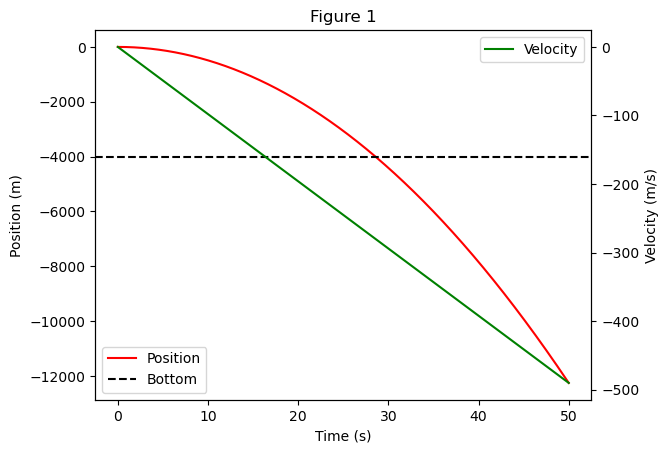

In [4]:
from scipy.integrate import solve_ivp
t0 = 0
tf = 50
x0 = 0
v0 = 0
alpha = 0
gam = 2
t_eval = np.linspace(t0, tf, 10000)
soln = solve_ivp(dydt_gravity, (t0, tf), [x0, v0], t_eval = t_eval)

tt = soln.t
pos = soln.y[0]
vel = soln.y[1]

fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(tt, pos, color = 'red', label = 'Position')
ax2.plot(tt, vel, color = 'green', label = 'Velocity')
ax.set_ylabel('Position (m)')
ax2.set_ylabel('Velocity (m/s)')
ax.set_xlabel('Time (s)')
ax.set_title('Figure 1')
ax.axhline(-4000, color = 'black', linestyle = '--', label = 'Bottom')
ax.legend(loc = 'lower left')
ax2.legend(loc = 'upper right')

In [5]:
def crash(t, s):
     """
    Takes in the time, position, and velocity argument and returns when the position has reached the bottom

    Args:
    t: Time in seconds
    s: An array with the position and velcoity argument

    Return:
    s[0] + 4000: The position at the bottom
    """
     return s[0] + 4000


crash.terminal = True
crash.direction = -1

soln1 = solve_ivp(dydt_gravity, (t0, tf), [x0, v0], t_eval = t_eval, events = crash)
print(f'Hit the Bottom at: {soln1.t_events[0][0]:5f} s')

Hit the Bottom at: 28.571429 s


## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



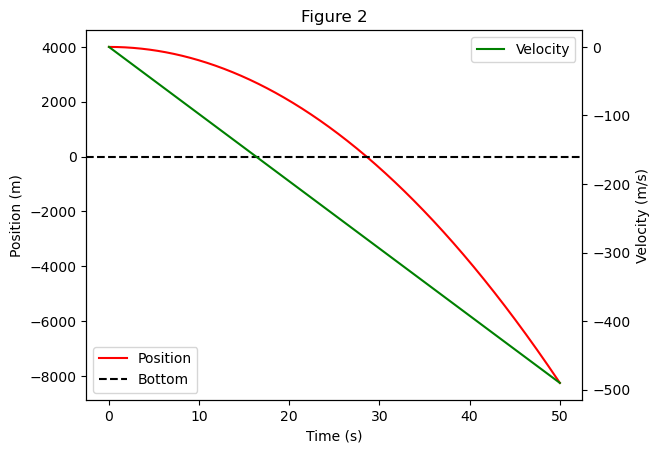

In [6]:
def new_dydt_gravity(t, s):
     """
    Takes in the time, position, and velocity argument and returns the velocity and acceleration argument

    Args:
    t: Time in seconds
    s: An array with the position in meters and velcoity argument in meters per second

    Return:
    D: An array with the velocity and acceleration argument using velocity as the second index of s and the acceleration as -g
    """
     D = np.zeros(2)           
     g = g0 * (s[0]/rad_earth)               
     D[0] = s[1]
     D[1] = -g
     return D

def new_crash(t, s):
    """
    Takes in the time, position, and velocity argument and returns the position when it reaches the bottom

    Args:
    t: Time in seconds
    s: An array with the position in meters and velcoity argument in meters per second

    Return:
    s[0] - (radius of the earth - 4000): Position when 4000 below the radius of the earth
    """
    return s[0] - (rad_earth - 4000)

t0 = 0
tf = 50
x0, v0 = rad_earth, 0
t_eval = np.linspace(t0, tf, 1000)
new_crash.direction = -1
soln = solve_ivp(new_dydt_gravity, (t0, tf), [x0, v0], t_eval = t_eval, events = new_crash)
tt = soln.t
pos = soln.y[0] - (rad_earth - 4000)
vel = soln.y[1]

fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(tt, pos, color = 'red', label = 'Position')
ax2.plot(tt, vel, color = 'green', label = 'Velocity')
ax.set_ylabel('Position (m)')
ax2.set_ylabel('Velocity (m/s)')
ax.set_xlabel('Time (s)')
ax.set_title('Figure 2')
ax.axhline(0, color = 'black', linestyle = '--', label = 'Bottom')
ax.legend(loc = 'lower left')
ax2.legend(loc = 'upper right')

The shaft is only 4000 m deep, whereas the radius of the earth if 6.37 x $10^6$ m deep, therefore g barely changes. The fall time therefore is only a time, unnoticeable amount longer.

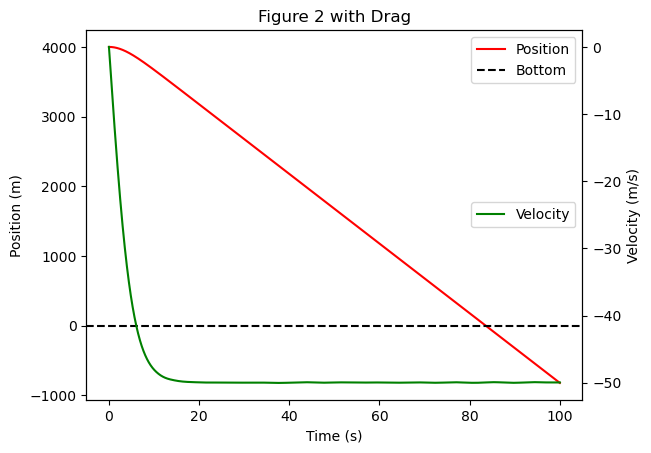

In [7]:
vt = 50
gamma = 2
alpha = g0/vt**gamma
x0, v0 = rad_earth, 0
def dydt_drag(t, s):
    """
    Takes in the time, position, and velocity argument and returns the velocity and acceleration argument

    Args:
    t: Time in seconds
    s: An array with the position in meters and velcoity argument in meters per second

    Return:
    D: An array with the velocity and acceleration argument using velocity as the second index of s and the acceleration as -9.8 + alpha * |velocity|^gamma
    """
    D = np.zeros(2)
    g = g0 * (s[0]/rad_earth)
    D[0] = s[1]
    D[1] = -g + alpha * abs(s[1])**gamma
    return D

t0 = 0
tf = 100
t_eval = np.linspace(t0, tf, 10000)

soln1 = solve_ivp(dydt_drag, (t0, tf), [x0, v0], t_eval = t_eval, events = new_crash)
tt = soln1.t
pos = soln1.y[0] - (rad_earth - 4000)
vel = soln1.y[1]

fig1, ax1 = plt.subplots()
ax3 = ax1.twinx()
ax1.plot(tt, pos, color = 'red', label = 'Position')
ax3.plot(tt, vel, color = 'green', label = 'Velocity')
ax1.set_ylabel('Position (m)')
ax3.set_ylabel('Velocity (m/s)')
ax1.set_xlabel('Time (s)')
ax1.set_title('Figure 2 with Drag')
ax1.axhline(0, color = 'black', linestyle = '--', label = 'Bottom')
ax1.legend(loc = 'upper right')
ax3.legend(loc = 'center right')

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




In [8]:
def dydt_coriolis(t, s):
    """
    Takes in the time, position in the x and y direction, and velocity in the x and y direction and returns the velocity in the x and y direction and acceleration argument in the x and y direction

    Args:
    t: Time in seconds
    s: An array with the position in the x and y direction in meters and velcoity argument in the x and y direction in meters per second

    Return:
    D: An array with the velocity and acceleration both in the x and y direction argument using velocity as the third and fourth index of s and the acceleration of x as 2 * omega * velocity of y and the acceleration in the y direction as g - 2 * omega * velocity of x
    """
    D = np.zeros(4)
    D[0] = s[2]
    D[1] = s[3]
    r = rad_earth - s[1]
    g = g0 * (r/rad_earth)
    D[2] = 2 * omega * s[3]
    D[3] = g - 2 * omega * s[2]
    return D

def crash_coriolis(t, s):
    """
    Takes in the time, position, and velocity argument and returns position at the bottom

    Args:
    t: Time in seconds
    s: An array with the position in meters and velcoity argument in meters per second

    Return:
    s[1] - 4000: When the mass has reached the bottom in the y direction
    """
    return s[1] - 4000

crash_coriolis.direction = 1
t0 = 0
tf = 50
x0, y0, vx0, vy0 = 0, 0, 0, 0
t_eval = np.linspace(t0, tf, 1000)
soln = solve_ivp(dydt_coriolis, (t0, tf), [x0, y0, vx0, vy0], t_eval = t_eval, events = crash_coriolis)
tt = soln.t
xx = soln.y[0]
yy = -soln.y[1]
print(f'Hit the bottom at: {soln.t_events[0][0]:.5f} s')
print(f'Sideways displacement: {soln.y[0, -1]:.5f} m')

Hit the bottom at: 28.55838 s
Sideways displacement: 29.71851 m


The mass will hit the wall before it reaches the bottom.


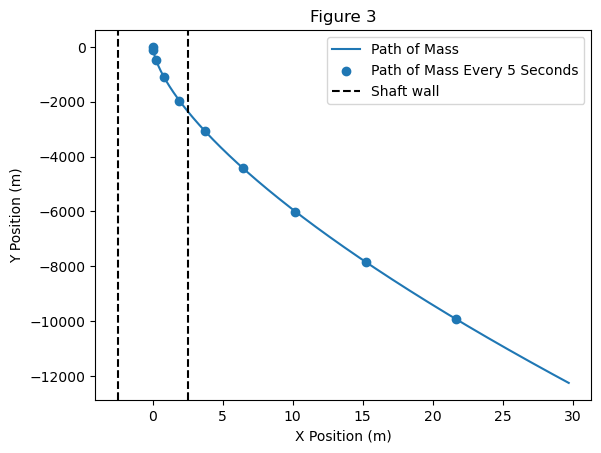

In [9]:
fig, ax = plt.subplots()
ax.plot(xx, yy, label = 'Path of Mass')
dots = np.arange(0, tt[-1], 5)
x_dots = np.interp(dots, tt, xx)
y_dots = np.interp(dots, tt, yy)
ax.scatter(x_dots, y_dots, label ='Path of Mass Every 5 Seconds')
ax.axvline(2.5, color = "black", linestyle = "--", label = "Shaft wall")
ax.axvline(-2.5, color = "black", linestyle = "--")
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title('Figure 3')
ax.legend()
print('The mass will hit the wall before it reaches the bottom.')

In [10]:
vt = 50
gamma = 2
alpha = g0/vt**gamma
def dydt_coriolis_drag(t, s):
    """
    Takes in the time, position in the x and y direction, and velocity in the x and y direction and returns the velocity in the x and y direction and acceleration argument in the x and y direction

    Args:
    t: Time in seconds
    s: An array with the position in the x and y direction in meters and velcoity argument in the x and y direction in meters per second

    Return:
    D: An array with the velocity and acceleration both in the x and y direction argument using velocity as the third and fourth index of s and the acceleration of x as 2 * omega * velocity of y and the acceleration in the y direction as g + drag - 2 * omega * velocity of x
    """
    D = np.zeros(4)
    r = rad_earth - s[1]
    g = g0 * (r/rad_earth)
    D[0] = s[2]
    D[1] = s[3]
    drag = -alpha * abs(s[3])**gamma
    D[2] = 2 * omega * s[3]
    D[3] = g + drag - 2 * omega * s[2]
    return D

crash_coriolis.direction = 1
t0 = 0
tf = 300
x0, y0, vx0, vy0 = 0, 0, 0, 0
t_eval = np.linspace(t0, tf, 1000)
soln1 = solve_ivp(dydt_coriolis_drag, (t0, tf), [x0, y0, vx0, vy0], t_eval = t_eval, events = crash_coriolis)
print(f'Hit the bottom with drag at: {soln1.t_events[0][0]:.5f} s')
print(f'Sideways displacement with drag: {soln1.y[0, -1]:.5f} m')

Hit the bottom with drag at: 83.54380 s
Sideways displacement with drag: 319.49410 m


## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





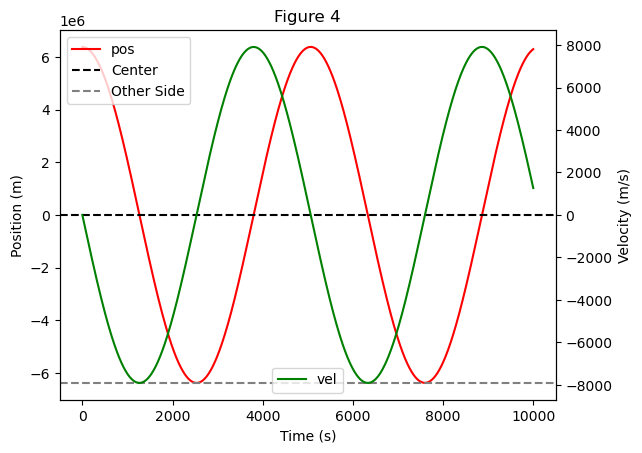

In [11]:
def dydt_infinite(t, s):
     """
    Takes in the time, position, and velocity argument and returns the velocity and acceleration argument

    Args:
    t: Time in seconds
    s: An array with the position in meters and velcoity argument in meters per second

    Return:
    D: An array with the velocity and acceleration argument using velocity as the second index of s and the acceleration as -9.8 * position/radius of the earth
    """
     D = np.zeros(2)
     D[0] = s[1]
     D[1] =  -g0 * s[0]/rad_earth
     return D

def reached_other_side(t, s):
     """
    Takes in the time, position, and velocity argument and returns the position when it reaches the other side

    Args:
    t: Time in seconds
    s: An array with the position in meters and velcoity argument in meters per second

    Return:
    s[1]: When the velocity is 0, therefore it has reached the other side
    """
     if t < 1:
        return -1
     return s[1]

reached_other_side.direction = 1

t0 = 0
tf = 10000
x0, v0 = rad_earth, 0
t_eval = np.linspace(t0, tf, 10000)
soln = solve_ivp(dydt_infinite, (t0, tf), [x0, v0], t_eval = t_eval, events = reached_other_side)

tt = soln.t
yy = soln.y[0]
vv = soln.y[1]

fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(tt, yy, color = 'red', label = 'pos')
ax2.plot(tt, vv, color = 'green', label = 'vel')
ax.axhline(0, color = 'black', linestyle = '--', label = 'Center')
ax.axhline(-rad_earth, color = 'grey', linestyle = '--', label = 'Other Side')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (m)')
ax2.set_ylabel('Velocity (m/s)')
ax.set_title('Figure 4')
ax.legend(loc = 'upper left')
ax2.legend(loc = 'lower center')

In [12]:
other_side = soln.t_events[0][0]
center = np.argmin(np.abs(yy))
center_time = other_side / 2
center_vel = abs(vv[center])

print(f'Time to reach other side: {other_side:.3f} s')
print(f'Time to reach center: {center_time:.3f} s')
print(f'Speed at center: {center_vel:.3f} m/s')

Time to reach other side: 2532.612 s
Time to reach center: 1266.306 s
Speed at center: 7912.359 m/s


In [13]:
v_orbit = np.sqrt(g0 * rad_earth)
T_orbit = 2 * np.pi * rad_earth/v_orbit

print(f'Orbit Time: {T_orbit:.3f} s')
print(f'Orbit Speed: {v_orbit:.3f} m/s')

Orbit Time: 5066.301 s
Orbit Speed: 7910.067 m/s


## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

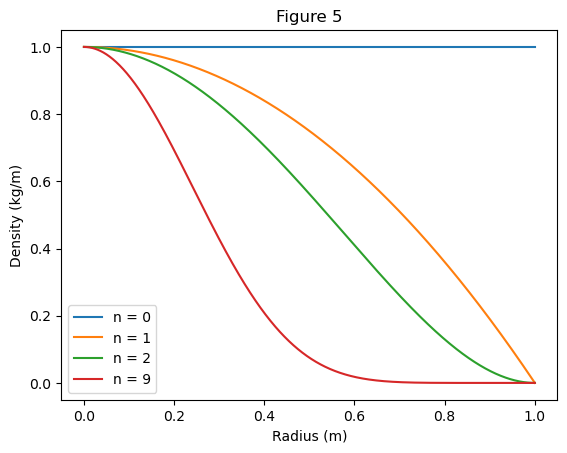

In [14]:
n_vals = [0, 1, 2, 9]
r_vals = np.linspace(0, rad_earth, 1000)

fig, ax = plt.subplots()
for n in n_vals:
    rho_norm = (1 - (r_vals/rad_earth)**2)**n
    ax.plot(r_vals/rad_earth, rho_norm, label = f'n = {n}')

ax.set_xlabel('Radius (m)')
ax.set_ylabel('Density (kg/m)')
ax.set_title('Figure 5')
ax.legend()

### Part 5, Section B (Forces)

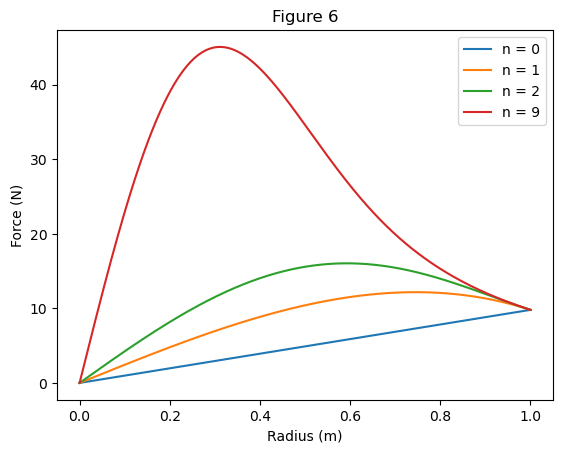

In [15]:
def rho_normal(n):
    """
    Takes in n and gives the mass over the entire Earth

    Args:
    n: The exponent of the density equation

    Returns:
    rho: The integral of the density function of the entire earth from 0 to the radius of the earth times the radius function squared which gives the mass of the earth in kilograms
    """
    integrand = lambda r: (1 - (r/rad_earth)**2)**n * r**2
    integral, error = quad(integrand, 0, rad_earth)
    rho = M_earth/(4 * np.pi * integral)
    return rho
    
def mass(r, n):
    """
    Takes in n and the desired radius and gives the mass for some arbitrary r

    Args:
    n: The exponent of the density equation
    r: An arbitrary radius in meters

    Returns:
    4 * pi * integral: The mass of the object from the integral in kilograms
    """
    rho = rho_normal(n)
    integrand = lambda rp: rho * (1 - (rp/rad_earth)**2)**n * rp**2
    integral, error = quad(integrand, 0, r)
    return 4 * np.pi * integral

def gravity(r, n):
    """
    Takes in n and some arbitrary radius and force of gravity for different radius values

    Args:
    n: The exponent of the density equation
    r: An arbitrary radius in meters

    Returns:
    np.array(g_vals): An array of the force of gravity for different r values
    """
    g_vals = []
    for r in r_vals:
        if r == 0:
            g_vals.append(0)
        else:
            M = mass(r, n)
            g_vals.append(G * M/r**2)
    return np.array(g_vals)

fig1, ax1 = plt.subplots()
g = {}

for n in n_vals:
    g_vals = gravity(r_vals, n)
    g[n] = g_vals
    ax1.plot(r_vals/rad_earth, g_vals, label = f'n = {n}')

ax1.set_xlabel('Radius (m)')
ax1.set_ylabel('Force (N)')
ax1.set_title('Figure 6')
ax1.legend()

### Part 5, Section C (Equations of Motion)

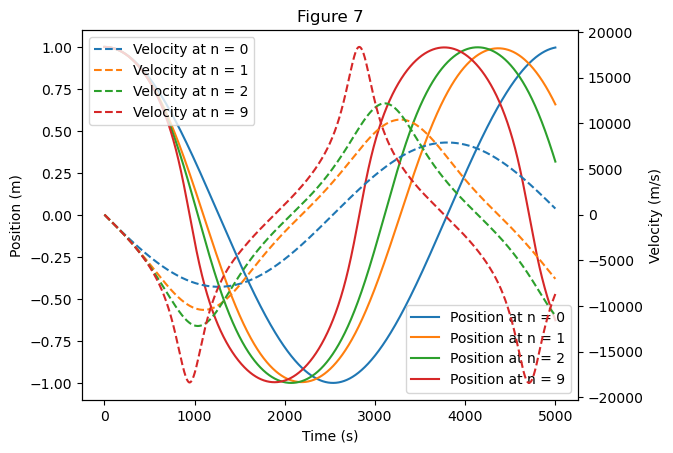

In [16]:
def make_g(n):
    """
    Creates a gravity function for different density values by index n

    Args:
    n: An index to idensitify which g to use

    Returns:
    interpld: A function to determine what to do when r is out of the known range
    """
    g_vals = g[n]
    return interp1d(r_vals, g_vals, bounds_error = False, fill_value = (0, g_vals[-1]))

def center(t, s):
     """
    Takes in the time, position, and velocity argument and returns the position when it reaches the center of the earth

    Args:
    t: Time in seconds
    s: An array with the position in meters and velcoity argument in meters per second

    Return:
    s[0]: The position at the center of the earth
    """
     return s[0]

center.direction = -1

fig2, ax2 = plt.subplots()
ax4 = ax2.twinx()

results = {}
t0 = 0
tf = 5000
t_eval = np.linspace(t0, tf, 10000)
x0, v0 = rad_earth, 0

for n in n_vals:
    g_func = make_g(n)
    def dydt(t, s):
        """
    Takes in the time, position, and velocity argument and returns the velocity and acceleration argument

    Args:
    t: Time in seconds
    s: An array with the position in meters and velcoity argument in meters per second

    Return:
    D: An array with the velocity and acceleration argument using velocity as the second index of s and the acceleration as 0 if the radius is 0 or sign(position) * g function
    """
        D = np.zeros(2)
        D[0] = s[1]
        r = np.abs(s[0])
        if r == 0:
            D[1] = 0
        else:
            D[1] = -np.sign(s[0]) * g_func(r)
        return D
    soln = solve_ivp(dydt, (t0, tf), [x0, v0], t_eval = t_eval, events = center)
    results[n] = soln
    tt = soln.t
    yy = soln.y[0]
    vv = soln.y[1]
    ax2.plot(tt, yy/rad_earth, label = f'Position at n = {n}')
    ax4.plot(tt, vv, linestyle = '--', label = f'Velocity at n = {n}')

ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Position (m)')
ax4.set_ylabel('Velocity (m/s)')
ax2.set_title('Figure 7')
ax2.legend()
ax4.legend()


In [17]:
for n in n_vals:
    t_center = results[n].t_events[0][0]
    speed = abs(results[n].y[1, -1])
    print(f' At n = {n}, the time to the center is {t_center:.3f} s and the speed is {speed:.5f} m/s')

 At n = 0, the time to the center is 1267.241 s and the speed is 666.99848 m/s
 At n = 1, the time to the center is 1096.890 s and the speed is 7033.98572 m/s
 At n = 2, the time to the center is 1035.146 s and the speed is 11058.17872 m/s
 At n = 9, the time to the center is 943.888 s and the speed is 8693.07806 m/s


## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


In [18]:
t_center_moon = (np.pi/2) * np.sqrt(rad_moon/g0_moon)
t_center_earth = (np.pi/2) * np.sqrt(rad_earth/g0)
print(f'The time to center of the moon is {t_center_moon:.3f} s and the time to the center of the earth is {t_center_earth:.3f} s')

The time to center of the moon is 1626.531 s and the time to the center of the earth is 1266.575 s


In [19]:
rho_earth = 3 * g0/(4 * np.pi * G * rad_earth)
rho_moon = 3 * g0_moon/(4* np.pi * G * rad_moon)
print(f'The density of the moon is {rho_moon:.3f} kg/m^3 and the density of the Earth is {rho_earth:.3f} kg/m^3')

The density of the moon is 3335.960 kg/m^3 and the density of the Earth is 5501.528 kg/m^3


The time to the center is proportional to the inverse square root of the density. Therefore, the density of the moon is less than the density of the earth, so the time to the center of the moon is greater than the time to the center of the earth.

## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

n = 0
Dominant Fequency: 0.00020 Hz
Dominant Period: 5000.16667 s
n = 9
Dominant Fequency: 0.00027 Hz
Dominant Period: 3750.12500 s


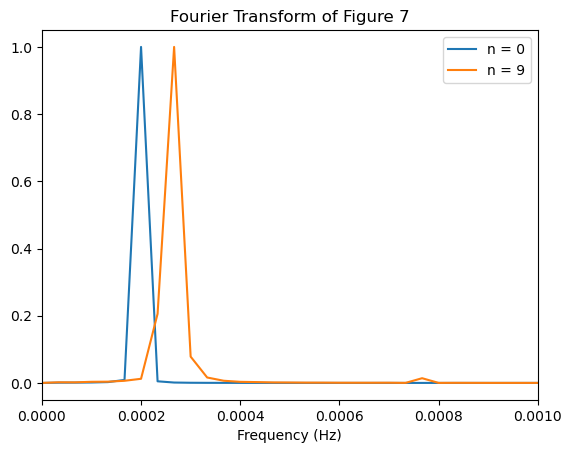

In [20]:
t0 = 0
tf = 30000
N = 30000
x0, v0 = rad_earth, 0
t_eval = np.linspace(t0, tf, N)

fft_results = {}
for n in [0, 9]:
    g_func = make_g(n)
    def dydt(t, s):
        """
    Takes in the time, position, and velocity argument and returns the velocity and acceleration argument

    Args:
    t: Time in seconds
    s: An array with the position in meters and velcoity argument in meters per second

    Return:
    D: An array with the velocity and acceleration argument using velocity as the second index of s and the acceleration as 0 if the radius is 0 or sign(position) * g function
    """
        D = np.zeros(2)
        D[0] = s[1]
        r = abs(s[0])
        if r == 0:
            D[1] = 0
        else:
            D[1] = -np.sign(s[0]) * g_func(r)
        return D
    soln = solve_ivp(dydt, (t0, tf), [x0, v0], t_eval = t_eval)
    y = soln.y[0]
    Y = np.fft.rfft(y - np.mean(y))
    freq = np.fft.rfftfreq(len(t_eval), d = t_eval[1] - t_eval[0])
    power = np.abs(Y)**2
    fft_results[n] = (freq, power)

fig, ax = plt.subplots()
for n in [0, 9]:
    freq, power = fft_results[n]
    ax.plot(freq, power/np.max(power), label = f'n = {n}')
    index = np.argmax(power[1:]) + 1
    dom_freq = freq[index]
    dom_period = 1/dom_freq
    print(f'n = {n}')
    print(f'Dominant Fequency: {dom_freq:.5f} Hz')
    print(f'Dominant Period: {dom_period:.5f} s')

ax.set_xlim(0, 0.001) 
ax.set_xlabel('Frequency (Hz)')
ax.set_label('Power (Watts)')
ax.set_title('Fourier Transform of Figure 7')
ax.legend()

Describe what we see here:

The fourier transform is dominated by one extreme frequency for each one. Since n = 0 is uniform, the motion is nearly perfect which is why the rest is constant. For n = 9, there are other peakes since the motion is not perfectly sin.